# Contact model

Let's make an 'upside-down' wedge, such that you might use to model the edge of a trap and a fluid contact. Not sure what to call this type of model, so let's go with **Contact model** until someone suggests a better name.

Some things I have not done in this notebook:

- Dealt at all with depth. Everything here is effectively in time sample indices or time.
- Think too hard about indexing leading to off-by-one errors, except for the initial model.
- Use a proper forward modelling method, it's 1D convolution only.
- Probably lots of other things.

## Requirements

You will need:

- `numpy`, `matplotlib`
- `bruges` for the reflectivity calculation and the wavelet

I use `bruges` for the convolution as well, but it's not hard to use `np.convolve()` with `np.apply_along_axis()` instead.

## Define a helper function

For time conversion.

In [2]:
import numpy as np
from scipy.interpolate import interp1d

def time_convert(vel, depth, dt, data):
    """
    Convert a regular depth scale to a regular
    time scale, and resample measurements on that
    depth scale to the time scale.

    Args:
        vel (ndarray): 1D velocity array.
        depth (ndarray): 1D depth array, must be
            regularly sampled.
        dt (float): The desired time interval in s.
        data (list): List of 1D data, eg logs.

    Returns:
        time (ndarray): 1D time array.
        data (list): The resampled data.
    """
    # Compute cumulative and linear time.
    dz = depth[1] - depth[0]
    cumt = np.cumsum(dz / vel)
    t = np.arange(0, cumt[-1], dt)

    # Time-convert the data.
    f = interp1d(cumt, data, bounds_error=False, kind='nearest')

    return t, f(t)

## Define the earth model

For now we use indices, no rock properties. The top layer will be 0, the second layer 1, etc.

In [3]:
def contact_model(depth, width, contact):
    """
    Construct a 'contact' model: sloping reservoir
    with flat contact.
    
    TODO:
      - Converge with wedge model code.
      - Allow non-flat contacts.
      - Provide other top-reservoir functions.
      - Do all this with xarray.DataArrays instead.
      - Explore separating lith model from fluid model.

    Args:
        depth (tuple): (left, right, bottom) in metres.
    """
    d1, d2, dmax = depth  # d0 is always 0 m.
    dmax += 1
    contact += 1
    earth = np.ones((dmax, width), dtype=int)

    # Define horizons.
    top = np.linspace(d1, d2, width)

    # Create the fluid contact.
    earth[contact:] = 2

    # Define the Top Reservoir and adjust values.
    idx = top.astype(int)
    rows = np.arange(dmax)[:, None]
    cols = np.arange(width)
    earth[rows <= idx[cols]] = 0

    # Make horizons we can plot.
    contact *= np.ones(width)
    contact = contact[contact > top + 1] - 1

    return earth, top, contact, np.arange(dmax)

Now we can define the earth model in depth:

In [4]:
depth = (125, 155, 300)
width = 90
contact = 150

earth, top, gwc, z = contact_model(depth, width, contact)

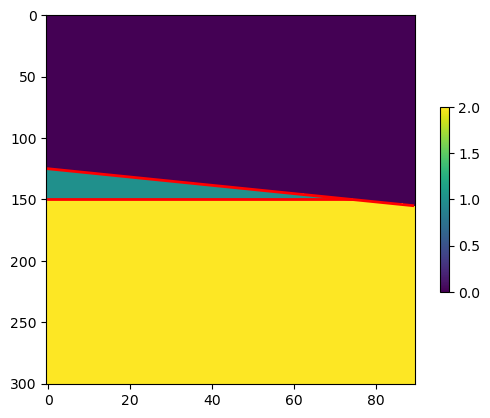

In [5]:
import matplotlib.pyplot as plt

plt.imshow(earth, interpolation='none', aspect=0.3)
plt.colorbar(shrink=0.5)
plt.plot(top, 'r-', lw=2)
plt.plot(gwc, 'r-', lw=2)

## Define some rocks

The order of the rocks must correspond to the indices in the earth model.

The triples here are Vp, Vs, rho. We use SI units.

In [6]:
rocks = np.array([
    # Vp     Vs   rho
    [2000,  700, 2100],
    [1800, 1200, 1900],
    [2300, 1150, 2150],
])

## Convert to time

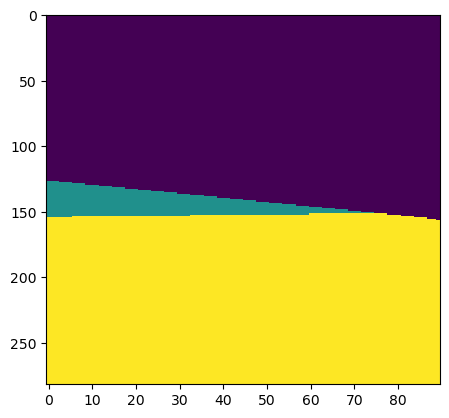

In [7]:
earth_t = []

for trace in earth.T:
    vp = rocks[trace][:, 0]
    time, tr_t = time_convert(vp, z, 0.0005, trace)
    earth_t.append(tr_t)

mint = min(len(tr) for tr in earth_t)
earth_t = np.array([t[:mint] for t in earth_t]).T
earth_t = np.nan_to_num(earth_t).astype(int)

plt.imshow(earth_t, interpolation='none', aspect=0.3)

## Define the petro-acoustic model

Now we inject the rock properties into the model using a NumPy indexing trick.

In [8]:
model = rocks[earth_t]

## Compute reflectivities

Use `bruges`, the default method is full Zoeppritz, computed for P-P reflections only. 

In [9]:
import bruges as bg

vp, vs, rho = model.T

r = bg.reflection.reflectivity(vp, vs, rho, theta=0, axis=1).T

We can look at this.

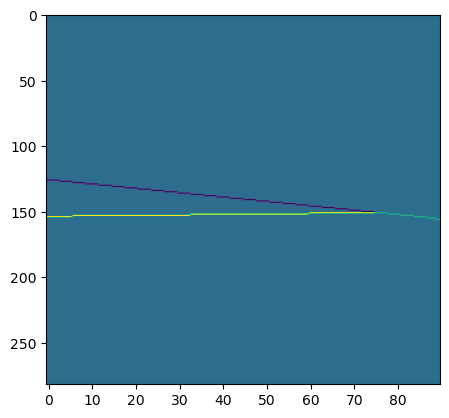

In [10]:
plt.imshow(r.real, aspect=0.3)

## Make a wavelet

It would be better to us, eg, a point-spread function, or to model with finite differences, eg see PyLops or Devito.

But we can do this:

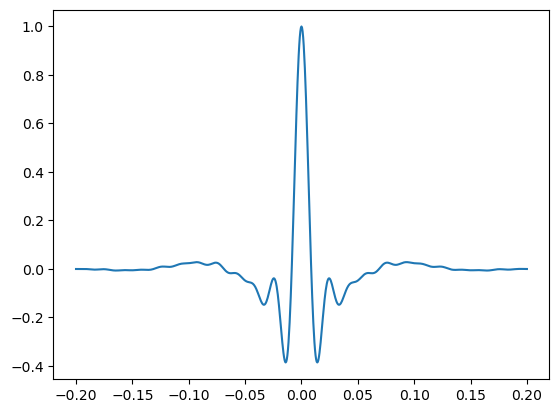

In [11]:
freq, pow = (5, 10, 40, 60), (0, 0)

w, t = bg.filters.ormsby_fft(duration=0.4, dt=0.0005, f=freq, P=pow)

plt.plot(t, w)

## Convolve

Again, this is far from ideal but it's a start. The main problem is the incorrect horizontal resolution.

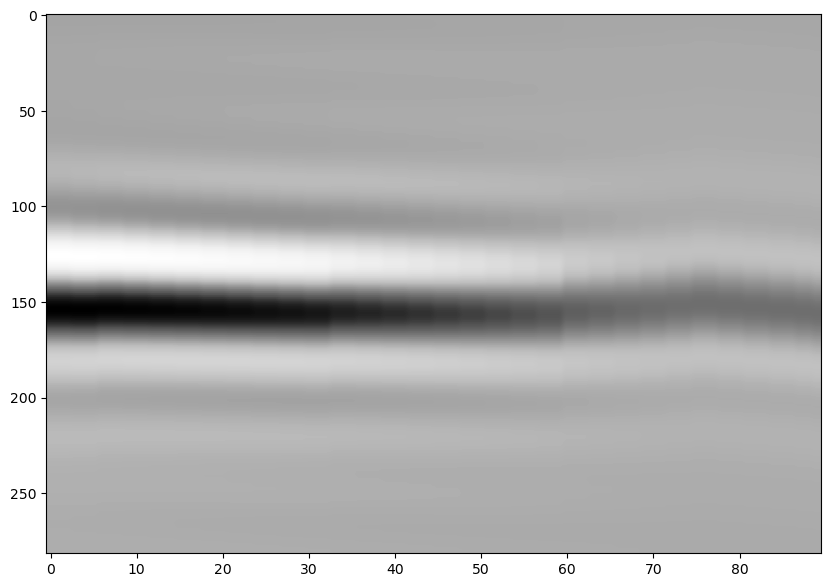

In [12]:
# This wavelet is too long, so we pad the reflectivity.
r_ = np.pad(r, pad_width=((400, 400), (0, 0)))

# Make the synthetic and chop the pads off.
s = bg.filters.convolve(r_, w, axis=0)[400:-400]

# Plot it.
plt.figure(figsize=(10, 7))
plt.imshow(s.real, cmap='Greys', aspect='auto')

---

&copy; Matt Hall 2024 | Licensed CC BY, please share this work.